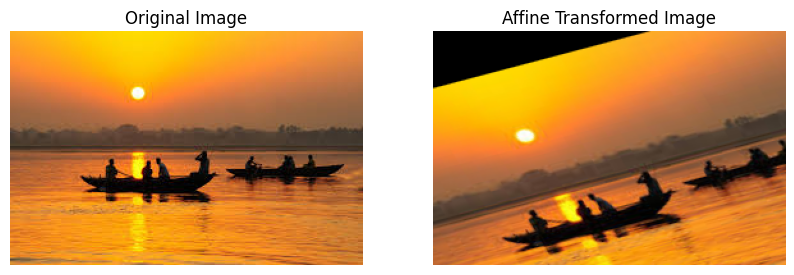

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# You can upload an image or use a sample image.
# For example, to upload, run the following in a new cell:
# from google.colab import files
# uploaded = files.upload()
# for filename in uploaded.keys():
#   img = cv2.imread(filename)
#   break

# For demonstration, let's create a dummy image or load a common one if available
# If you have an image file, replace 'input_image.jpg' with your image path
try:
    # Try to load a sample image (e.g., from OpenCV's samples or a common dataset)
    # If you have your own image, replace 'input_image.jpg' with your file name
    img = cv2.imread('nature image.jpeg') # Changed to load 'nature image.jpeg'
    if img is None:
        print("Image 'nature image.jpeg' not found. Creating a dummy image for demonstration.")
        # Create a dummy image (e.g., a blue square)
        img = np.zeros((300, 400, 3), dtype=np.uint8)
        cv2.rectangle(img, (50, 50), (250, 250), (255, 0, 0), -1) # Blue rectangle
        cv2.putText(img, 'Original Image', (70, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

except FileNotFoundError:
    print("Creating a dummy image as 'nature image.jpeg' was not found.")
    img = np.zeros((300, 400, 3), dtype=np.uint8)
    cv2.rectangle(img, (50, 50), (250, 250), (255, 0, 0), -1) # Blue rectangle
    cv2.putText(img, 'Original Image', (70, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)


if img is None:
    print("Error: Could not load or create image.")
else:
    rows, cols, ch = img.shape

    # Define 3 points on the original image
    pts1 = np.float32([[50,50],[200,50],[50,200]])
    # Define 3 corresponding points on the transformed image
    pts2 = np.float32([[10,100],[200,50],[100,250]])

    # Get the affine transformation matrix
    M = cv2.getAffineTransform(pts1,pts2)

    # Apply the affine transformation
    dst = cv2.warpAffine(img,M,(cols,rows))

    # Display the original and transformed images
    plt.figure(figsize=(10, 5))

    plt.subplot(121)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    plt.title('Affine Transformed Image')
    plt.axis('off')

    plt.show()
